In [1]:
import sys
import os
# get to project root
os.chdir('..')
print(os.getcwd())

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import seaborn as sns
import copy

In [3]:
cc_data_path = r".\data\cc_halving_single_round040426.json"
cc_tri_data_path = r".\data\cc_bounded_nn_single_round040426.json"

Loading data from .\data\cc_halving_single_round040426.json...
Found common trap sizes: ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '30', '60', '120']


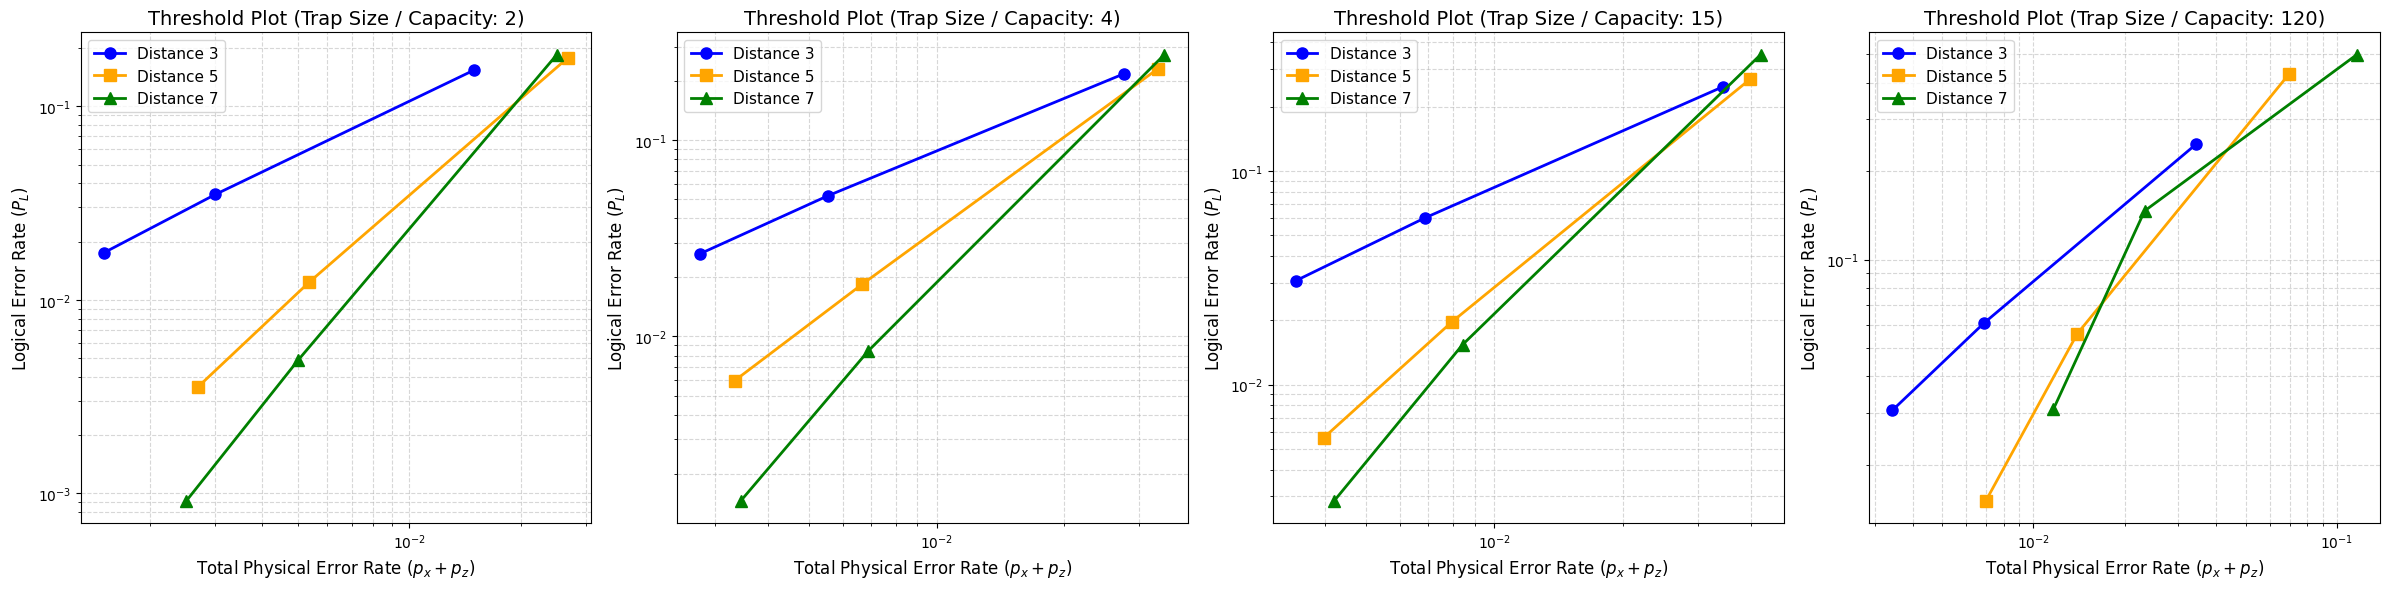

Loading data from .\data\cc_bounded_nn_single_round040426.json...
Found common trap sizes: ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '30', '60', '120']


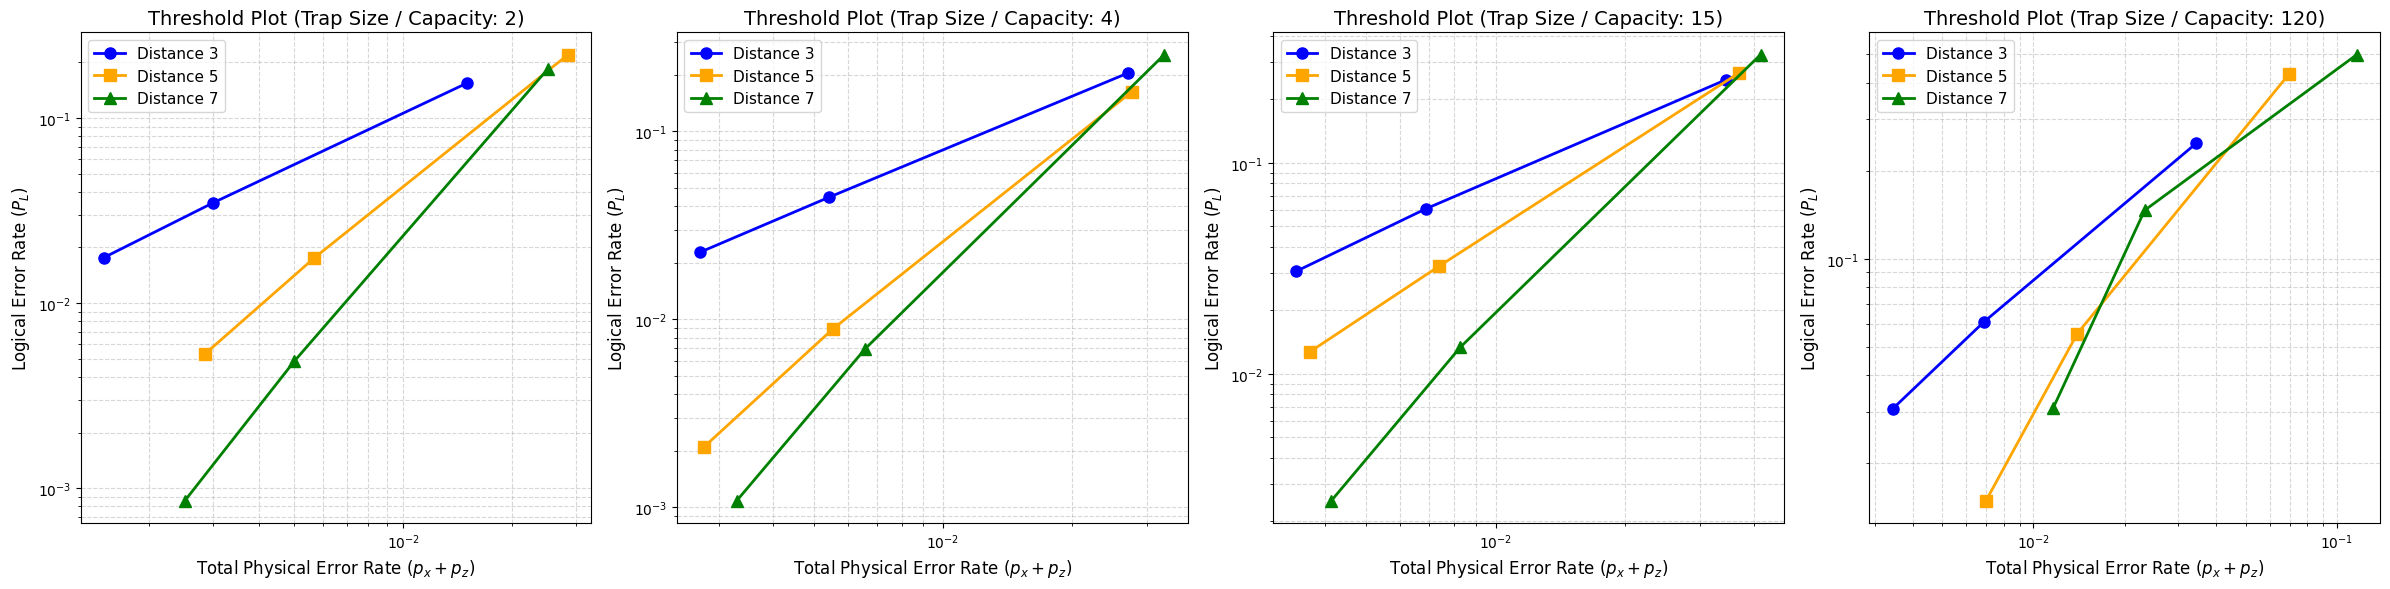

In [4]:

def generate_threshold_plots(json_filepath, target_trap_sizes=None):
    """
    Generates threshold plots from the QEC simulation JSON data.
    
    Args:
        json_filepath (str): Path to the JSON data file.
        target_trap_sizes (list): List of strings representing trap sizes to plot. 
                                  If None, a default representative set is chosen.
    """
    # 1. Load the JSON data
    print(f"Loading data from {json_filepath}...")
    with open(json_filepath, 'r') as f:
        data = json.load(f)

    # 2. Extract the relevant metric dictionaries
    logical_rates = data['LogicalErrorRates']['Forwarding']
    phys_x_rates = data['PhysicalXErrorRates']['Forwarding']
    phys_z_rates = data['PhysicalZErrorRates']['Forwarding']

    # Get available code distances as integers and sort them
    distances = sorted([int(d) for d in logical_rates.keys()])
    
    # Find common trap sizes (capacities) across all distances
    common_capacities = set(logical_rates[str(distances[0])].keys())
    for d in distances[1:]:
        common_capacities &= set(logical_rates[str(d)].keys())
    
    # Sort capacities numerically for clean ordering
    sorted_capacities = sorted(list(common_capacities), key=int)
    print(f"Found common trap sizes: {sorted_capacities}")

    # Select which trap sizes to plot (default to a few varied sizes if none provided)
    if target_trap_sizes is None:
        # Example: Pick a small, medium, and large capacity from the available list
        target_trap_sizes = ['4', '15', '60']
        # Ensure the defaults actually exist in the data
        target_trap_sizes = [t for t in target_trap_sizes if t in sorted_capacities]

    # 3. Create a figure with subplots for each selected trap size
    num_plots = len(target_trap_sizes)
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6), squeeze=False)
    axes = axes.flatten()

    # Define some standard markers/colors for distances
    markers = {3: 'o', 5: 's', 7: '^'}
    colors = {3: 'blue', 5: 'orange', 7: 'green'}

    # 4. Loop through each trap size and plot the threshold curves
    for i, trap_size in enumerate(target_trap_sizes):
        ax = axes[i]
        
        for d in distances:
            d_str = str(d)
            
            # Extract logical rates (Y-axis)
            y_vals = logical_rates[d_str][trap_size]
            
            # Extract and sum physical X and Z rates (X-axis proxy)
            x_vals_x = phys_x_rates[d_str][trap_size]
            x_vals_z = phys_z_rates[d_str][trap_size]
            x_vals_total = [x + z for x, z in zip(x_vals_x, x_vals_z)]
            
            # Plot the line for this distance
            ax.plot(x_vals_total, y_vals, 
                    marker=markers.get(d, 'x'), 
                    color=colors.get(d, 'black'), 
                    linestyle='-', 
                    linewidth=2, 
                    markersize=8,
                    label=f'Distance {d}')

        # Formatting the subplot
        ax.set_title(f'Threshold Plot (Trap Size / Capacity: {trap_size})', fontsize=14)
        ax.set_xlabel('Total Physical Error Rate ($p_x + p_z$)', fontsize=12)
        ax.set_ylabel('Logical Error Rate ($P_L$)', fontsize=12)
        
        # Set both axes to logarithmic scale
        ax.set_xscale('log')
        ax.set_yscale('log')
        
        # Add gridlines for readability
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.legend(fontsize=11)

    plt.tight_layout()
    
    # Save the figure and show it
    #output_filename = 'qec_threshold_plots.png'
    #plt.savefig(output_filename, dpi=300)
    #print(f"Plot saved successfully as {output_filename}")
    plt.show()

# You can change the trap sizes in this list to explore other capacities
# e.g., target_sizes = ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '30', '60', '120']
target_sizes = ['2', '4', '15', '120'] 

generate_threshold_plots(cc_data_path, target_trap_sizes=target_sizes)
generate_threshold_plots(cc_tri_data_path, target_trap_sizes=target_sizes)

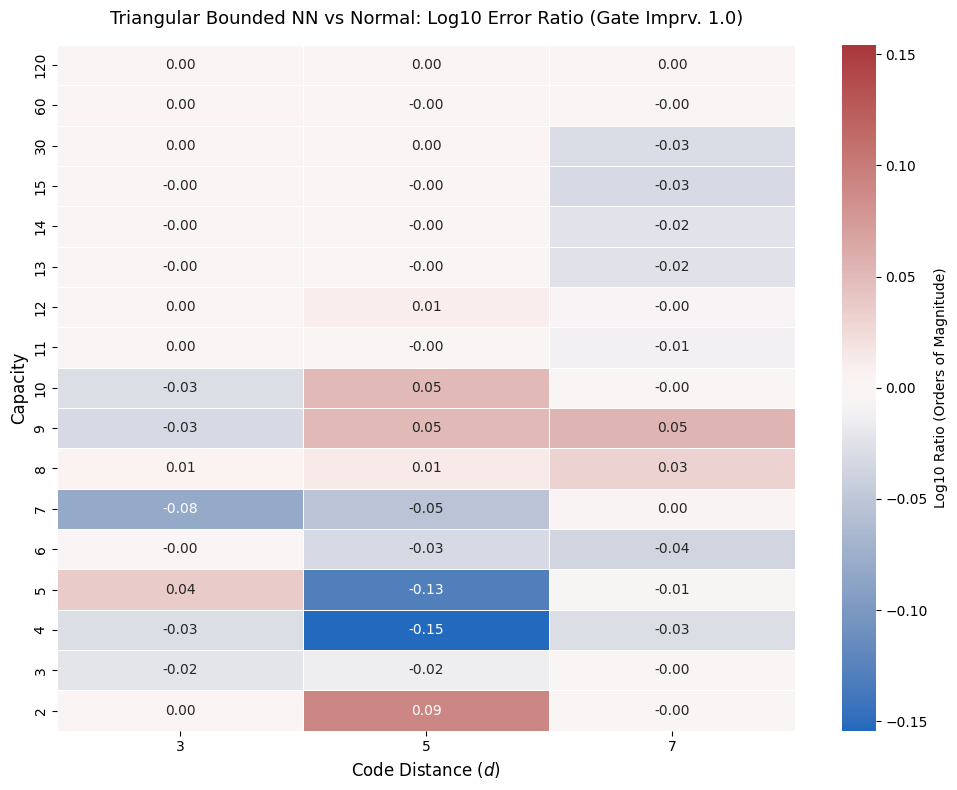

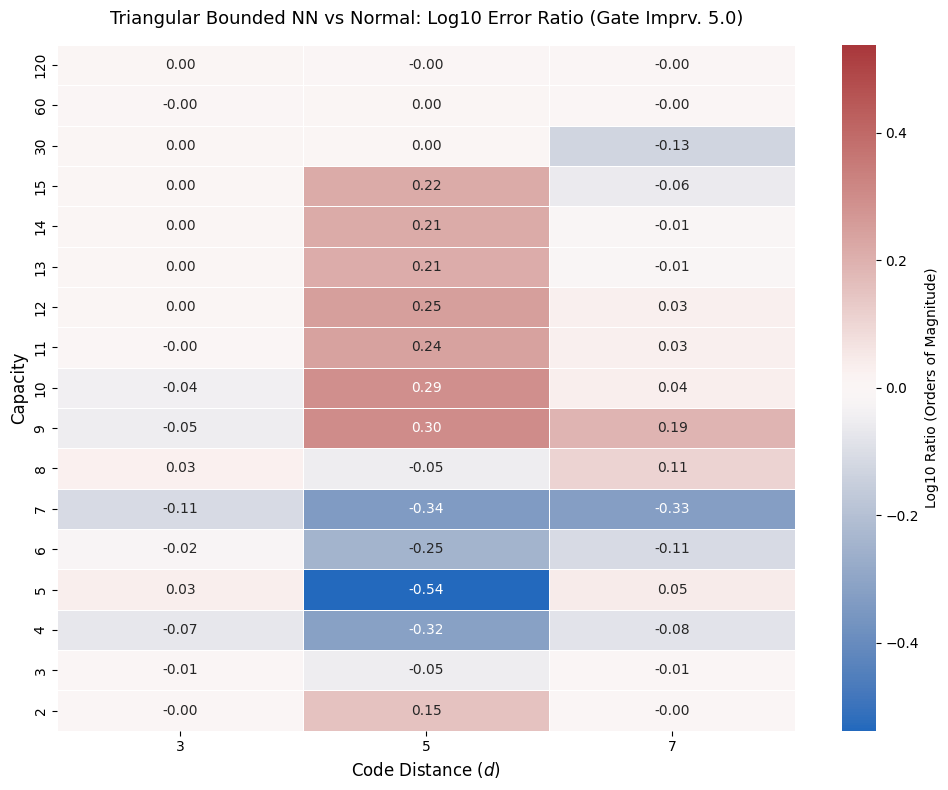

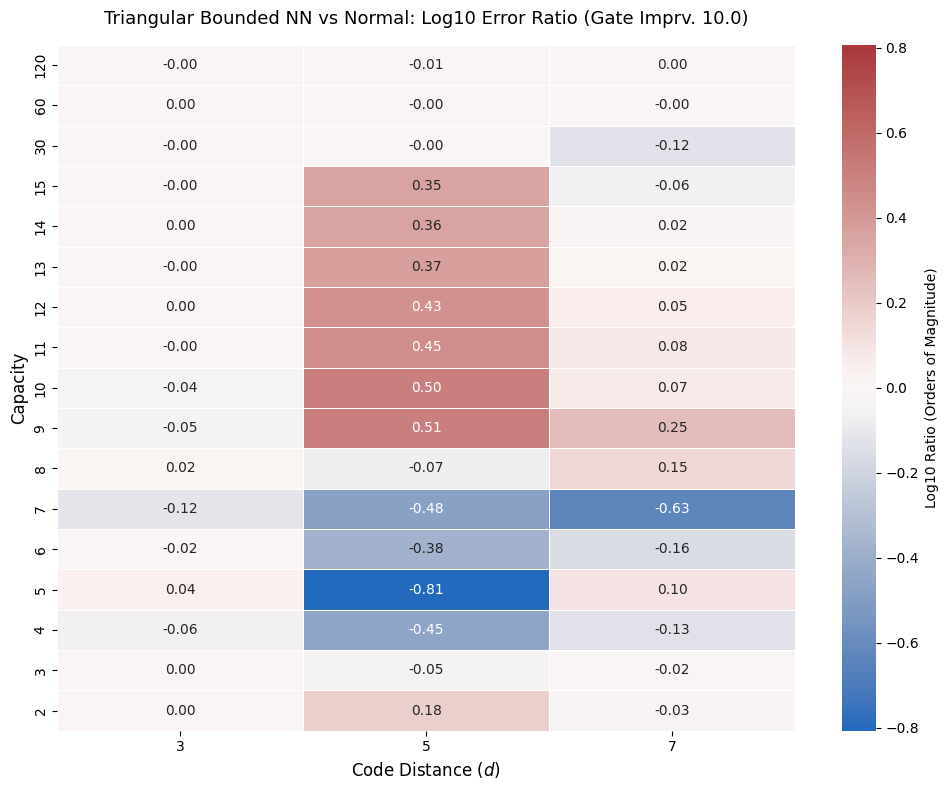

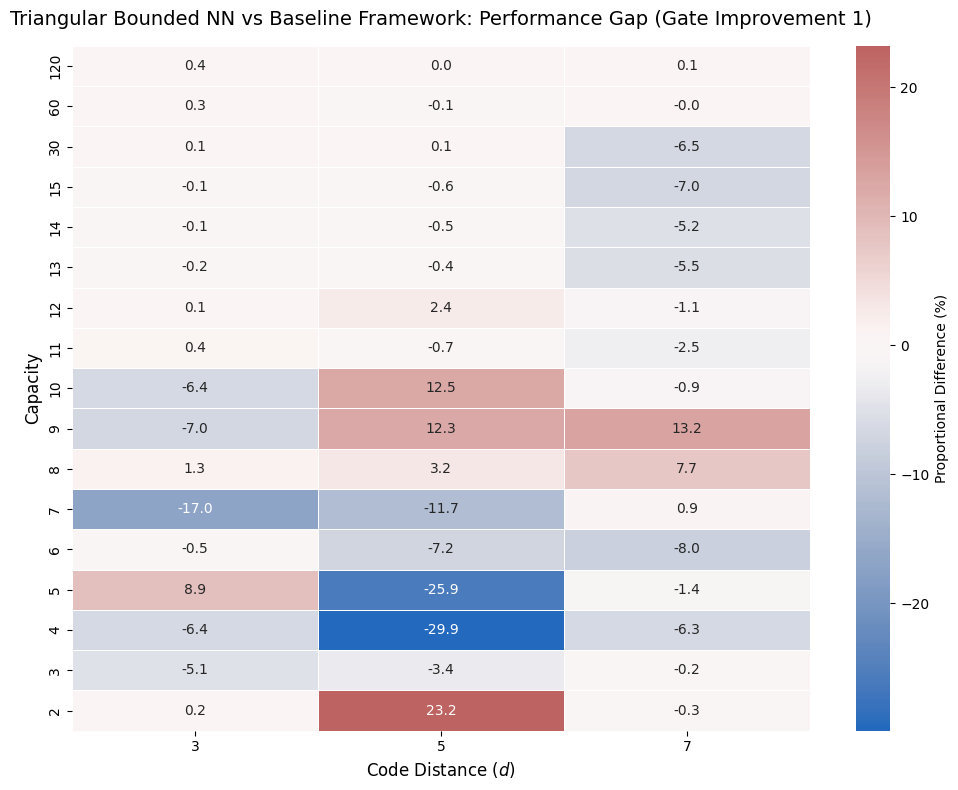

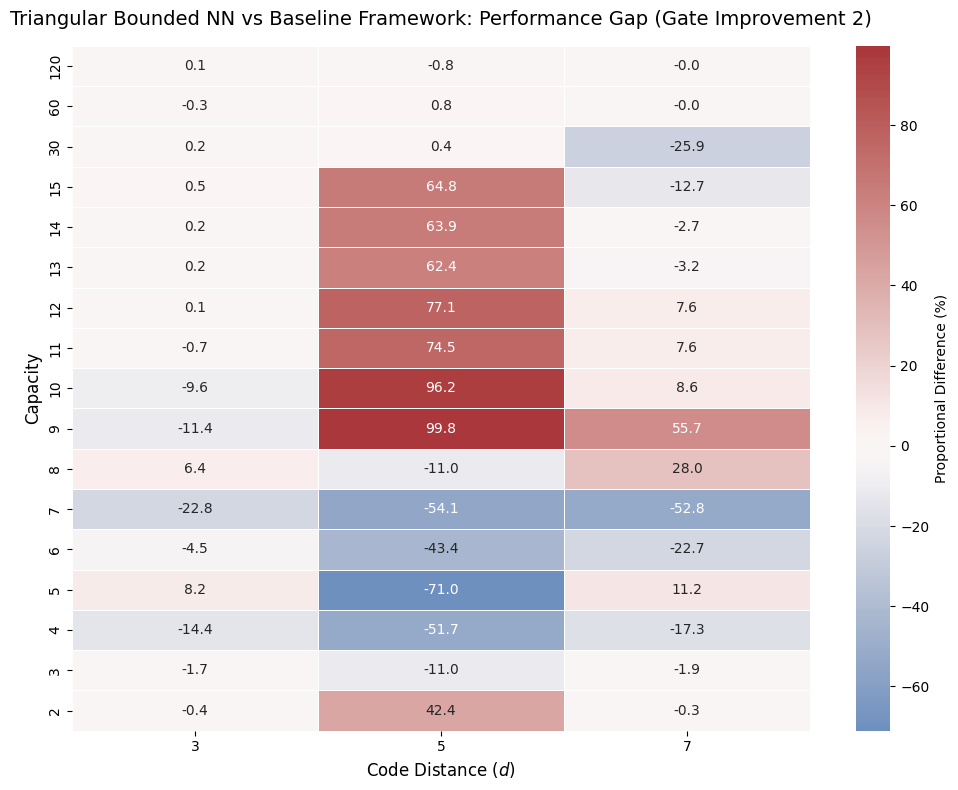

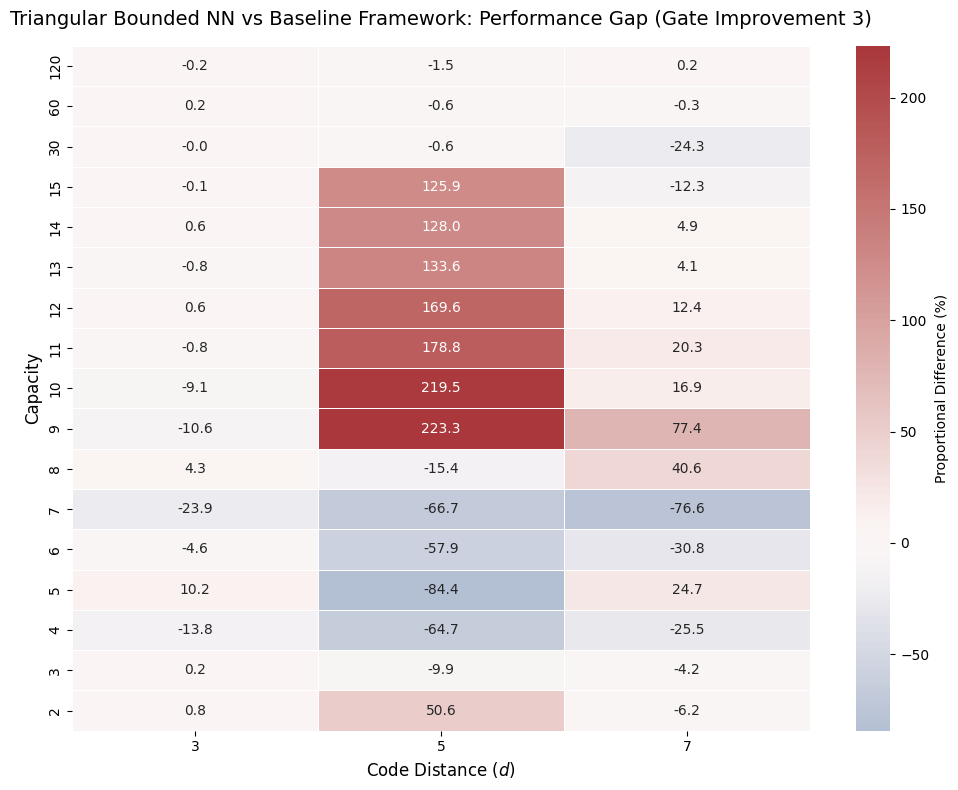

In [10]:
#heatmap generation to compare LER per gate improvement


def load_data(filepath):
    """Helper function to load the JSON data."""
    with open(filepath, 'r') as f:
        return json.load(f)

def generate_performance_heatmaps(json_baseline, json_new, label_baseline="Normal", label_new="Sierpinski"):
    """
    Generates comparative heatmaps, explicitly displaying NaN for missing data.
    """
    # 1. Load data
    data_baseline = load_data(json_baseline)['LogicalErrorRates']['Forwarding']
    data_new = load_data(json_new)['LogicalErrorRates']['Forwarding']

    # 2. Extract and sort Distances globally
    all_distances = set(data_baseline.keys()).union(set(data_new.keys()))
    distances = sorted([int(d) for d in all_distances])
    
    # 3. Extract and sort Capacities globally
    all_capacities = set()
    for dist_dict in data_baseline.values():
        all_capacities.update(dist_dict.keys())
    for dist_dict in data_new.values():
        all_capacities.update(dist_dict.keys())
        
    capacities_int = sorted([int(c) for c in all_capacities], reverse=True)
    capacities = [str(c) for c in capacities_int]

    num_gate_improvements = 0
    for d in data_baseline.values():
        for c in d.values():
            num_gate_improvements = max(num_gate_improvements, len(c))

    for factor_idx in range(num_gate_improvements):
        heatmap_data = []

        # 4. Populate the matrix
        for cap in capacities:
            row = []
            for dist in distances:
                dist_str = str(dist)
                
                rates_base = data_baseline.get(dist_str, {}).get(cap)
                rates_new = data_new.get(dist_str, {}).get(cap)
                
                if (rates_base is not None and rates_new is not None and 
                    len(rates_base) > factor_idx and len(rates_new) > factor_idx):
                    
                    val_base = rates_base[factor_idx]
                    val_new = rates_new[factor_idx]
                    
                    if val_base == 0:
                        prop_diff = np.nan
                    else:
                        prop_diff = ((val_new - val_base) / val_base) * 100
                else:
                    prop_diff = np.nan
                    
                row.append(prop_diff)
                
            heatmap_data.append(row)

        df = pd.DataFrame(heatmap_data, index=capacities, columns=distances)

        # 5. Create custom text annotations
        # This ensures valid numbers get 1 decimal place, and NaNs get explicitly labeled
        annot_array = np.empty_like(df.values, dtype=object)
        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                val = df.iloc[i, j]
                if pd.isna(val):
                    annot_array[i, j] = "NaN"
                else:
                    annot_array[i, j] = f"{val:.1f}"

        # 6. Plotting
        plt.figure(figsize=(10, 8))
        
        # Make a copy of the colormap so we don't modify the global default
        cmap = copy.copy(plt.get_cmap("vlag"))
        # Tell the colormap to color all NaN values dark gray
        cmap.set_bad("darkgray") 

        # Create the heatmap
        sns.heatmap(df, 
                    annot=annot_array, # Feed it our custom text array
                    fmt="",            # Leave format empty since the array is already formatted strings
                    cmap=cmap, 
                    center=0,
                    cbar_kws={'label': 'Proportional Difference (%)'},
                    linewidths=.5)

        plt.title(f'{label_new} vs {label_baseline}: Performance Gap (Gate Improvement {factor_idx + 1})', fontsize=14, pad=15)
        plt.xlabel('Code Distance ($d$)', fontsize=12)
        plt.ylabel('Capacity', fontsize=12)

        plt.tight_layout()
        #output_filename = f'heatmap_nan_comparison_factor_{factor_idx + 1}.png'
        #plt.savefig(output_filename, dpi=300)
        #print(f"Saved: {output_filename}")
        
        plt.show()

def generate_log_ratio_heatmaps(json_baseline, json_new, label_baseline="Normal", label_new="Sierpinski"):
    """
    Generates comparative heatmaps using Log10 Ratio to handle varying orders of magnitude.
    """
    data_baseline = load_data(json_baseline)['LogicalErrorRates']['Forwarding']
    data_new = load_data(json_new)['LogicalErrorRates']['Forwarding']

    # Extract globally unique distances and capacities
    all_distances = set(data_baseline.keys()).union(set(data_new.keys()))
    distances = sorted([int(d) for d in all_distances])
    
    all_capacities = set()
    for dist_dict in data_baseline.values():
        all_capacities.update(dist_dict.keys())
    for dist_dict in data_new.values():
        all_capacities.update(dist_dict.keys())
        
    capacities_int = sorted([int(c) for c in all_capacities], reverse=True)
    capacities = [str(c) for c in capacities_int]

    num_gate_improvements = 0
    for d in data_baseline.values():
        for c in d.values():
            num_gate_improvements = max(num_gate_improvements, len(c))
    gate_improvements = [1.0, 5.0, 10.0]
    
    for factor_idx in range(num_gate_improvements):
        heatmap_data = []

        # Populate the matrix with Log10 Ratios
        for cap in capacities:
            row = []
            for dist in distances:
                dist_str = str(dist)
                
                rates_base = data_baseline.get(dist_str, {}).get(cap)
                rates_new = data_new.get(dist_str, {}).get(cap)
                
                if (rates_base is not None and rates_new is not None and 
                    len(rates_base) > factor_idx and len(rates_new) > factor_idx):
                    
                    val_base = rates_base[factor_idx]
                    val_new = rates_new[factor_idx]
                    
                    if val_base == 0 or val_new == 0:
                        log_ratio = np.nan
                    else:
                        # Calculate Order of Magnitude difference
                        log_ratio = np.log10(val_new / val_base)
                else:
                    log_ratio = np.nan
                    
                row.append(log_ratio)
                
            heatmap_data.append(row)

        df = pd.DataFrame(heatmap_data, index=capacities, columns=distances)

        # Create custom text annotations formatted to 2 decimal places
        annot_array = np.empty_like(df.values, dtype=object)
        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                val = df.iloc[i, j]
                if pd.isna(val):
                    annot_array[i, j] = "NaN"
                else:
                    # e.g., "-1.05" means just over 1 order of magnitude better
                    annot_array[i, j] = f"{val:.2f}"

        plt.figure(figsize=(10, 8))
        
        cmap = copy.copy(plt.get_cmap("vlag"))
        cmap.set_bad("darkgray") 

        # We set specific vmin and vmax so the color scale doesn't get completely 
        # skewed by a single massive outlier (e.g. clipping at +/- 1.5 orders of magnitude).
        # You can adjust vmax and vmin based on your actual data distribution.
        max_abs_val = df.abs().max().max()
        limit = min(max_abs_val, 2.0) # Cap the color scale at 2 orders of magnitude max

        sns.heatmap(df, 
                    annot=annot_array, 
                    fmt="",            
                    cmap=cmap, 
                    center=0,
                    vmin=-limit,
                    vmax=limit,
                    cbar_kws={'label': 'Log10 Ratio (Orders of Magnitude)'},
                    linewidths=.5)

        plt.title(f'{label_new} vs {label_baseline}: Log10 Error Ratio (Gate Imprv. {gate_improvements[factor_idx]})', fontsize=13, pad=15)
        plt.xlabel('Code Distance ($d$)', fontsize=12)
        plt.ylabel('Capacity', fontsize=12)

        plt.tight_layout()
        #output_filename = f'heatmap_logratio_factor_{factor_idx + 1}.png'
        #plt.savefig(output_filename, dpi=300)
        #print(f"Saved: {output_filename}")
        
        plt.show()

generate_log_ratio_heatmaps(cc_data_path, cc_tri_data_path, label_baseline="Normal", label_new="Triangular Bounded NN")
    
#baseline_file = "cc_bounded_nn_single_round040426_normal.json"
#new_strategy_file = "cc_bounded_nn_single_round040426_sierpinski.json"

# You can customize the labels to match your specific mapping strategies
generate_performance_heatmaps(cc_data_path, cc_tri_data_path, label_baseline="Baseline Framework", label_new="Triangular Bounded NN")

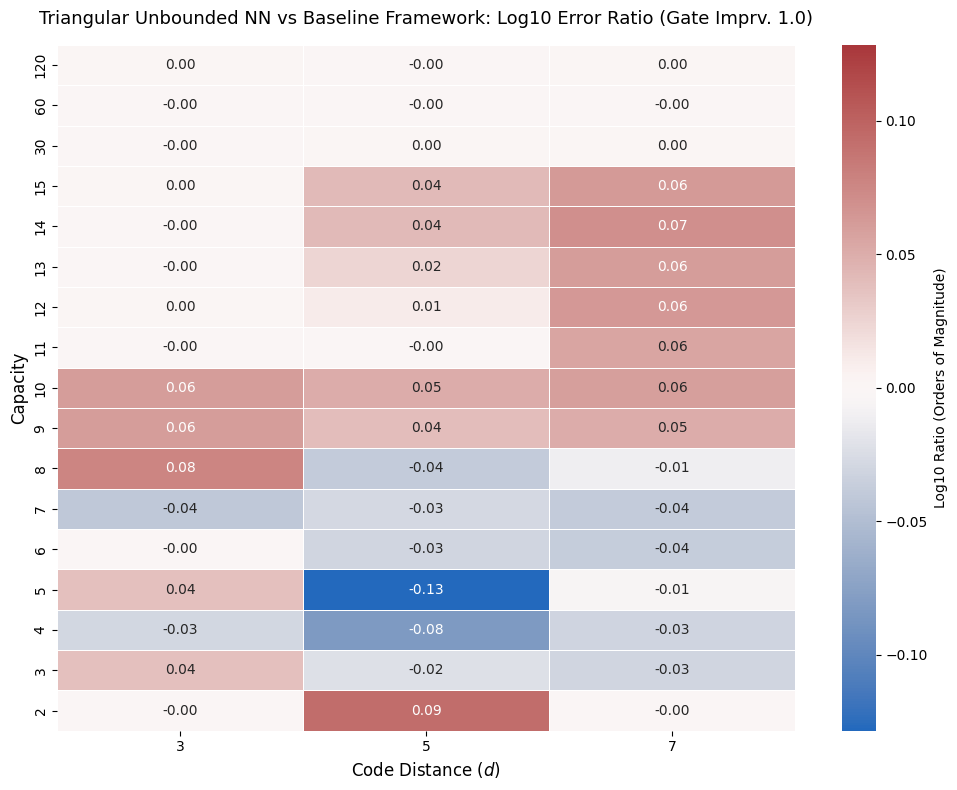

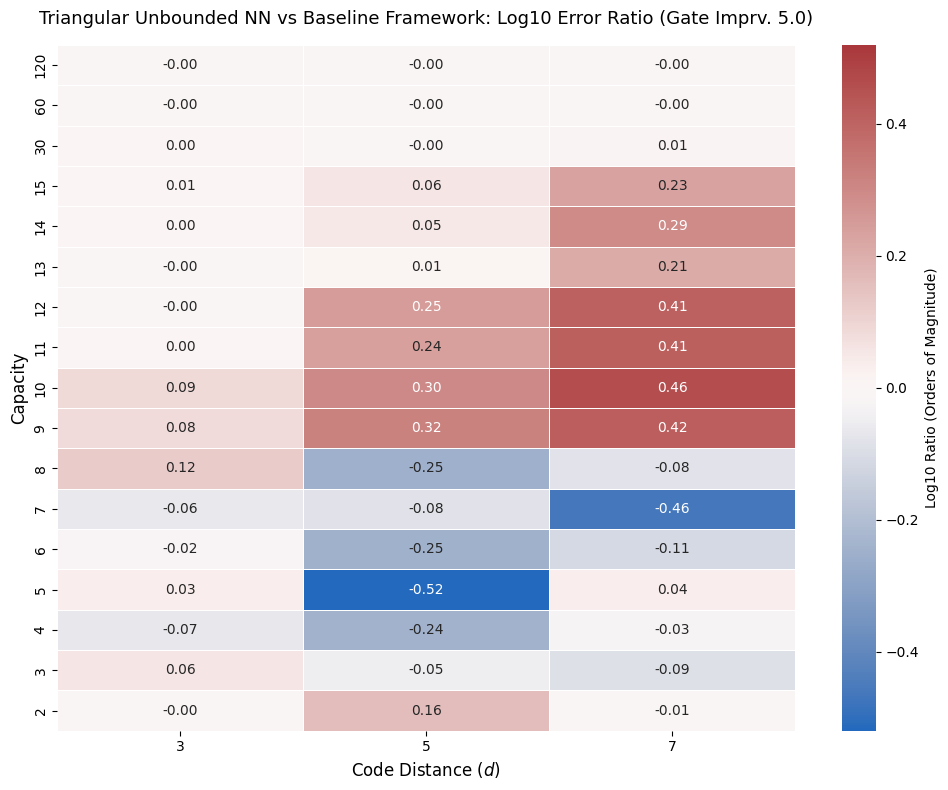

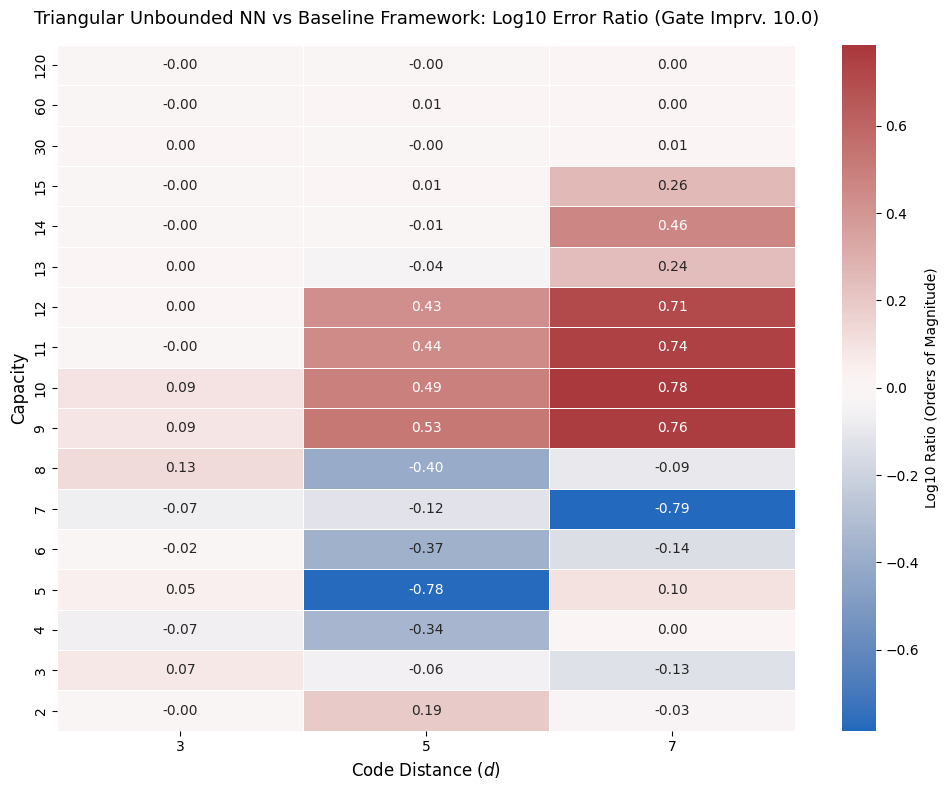

In [12]:
#heatmap generation for 1-round circuit
baseline_path = r".\data\cc_halving_single_round040426.json"
data_path = r".\data\cc_unbounded_nn_single_round040426.json"

generate_log_ratio_heatmaps(baseline_path, data_path, label_baseline="Baseline Framework", label_new="Triangular Unbounded NN")

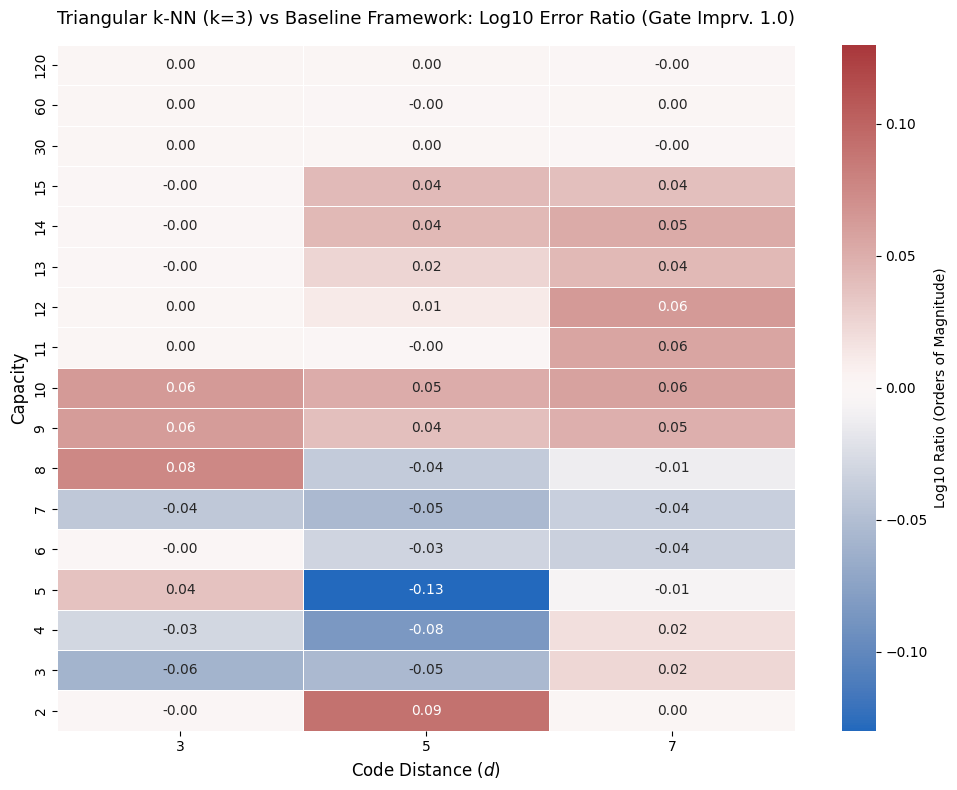

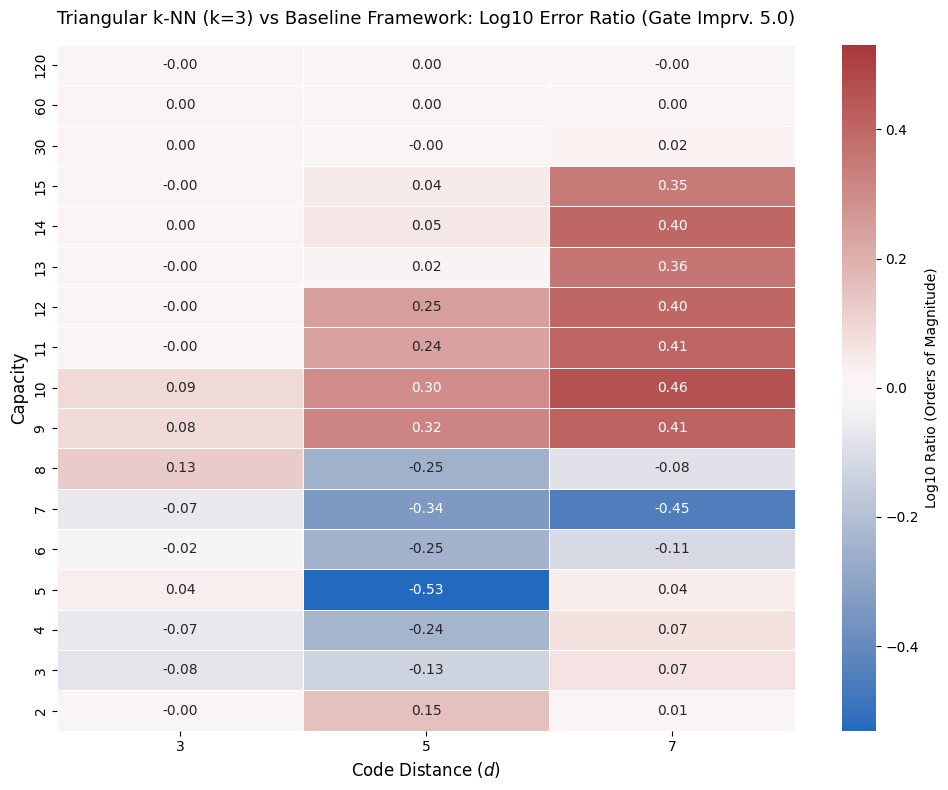

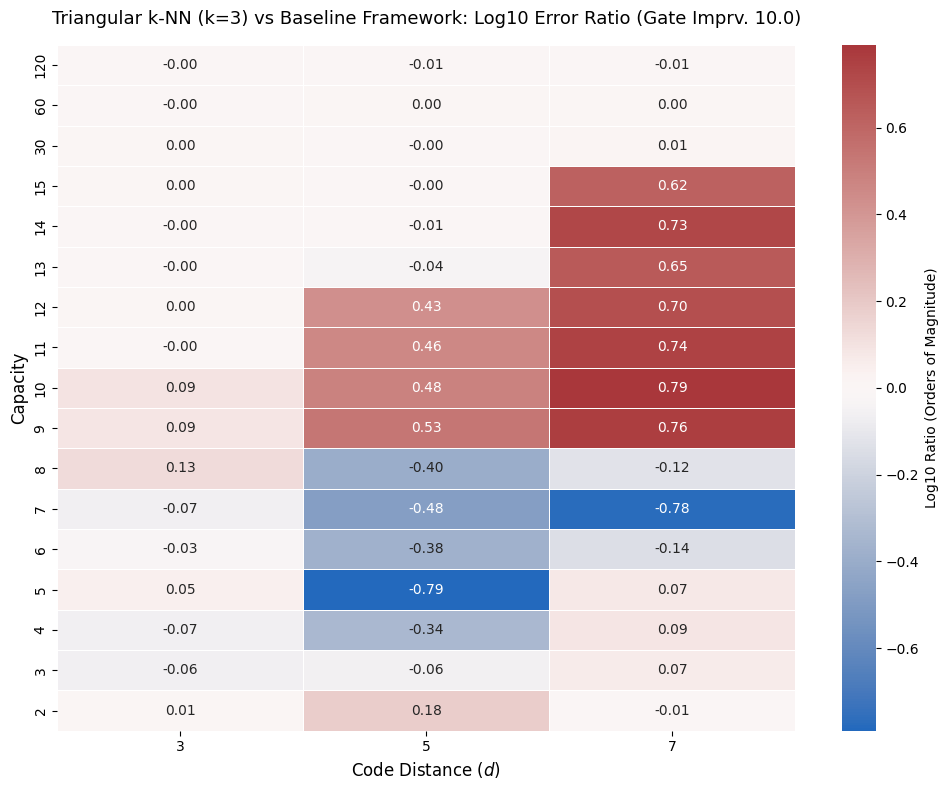

In [11]:
#heatmap generation for 1-round circuit
baseline_path = r".\data\cc_halving_single_round040426.json"
data_path = r".\data\cc_k=3_knn_single_round040426.json"

generate_log_ratio_heatmaps(baseline_path, data_path, label_baseline="Baseline Framework", label_new="Triangular k-NN (k=3)")

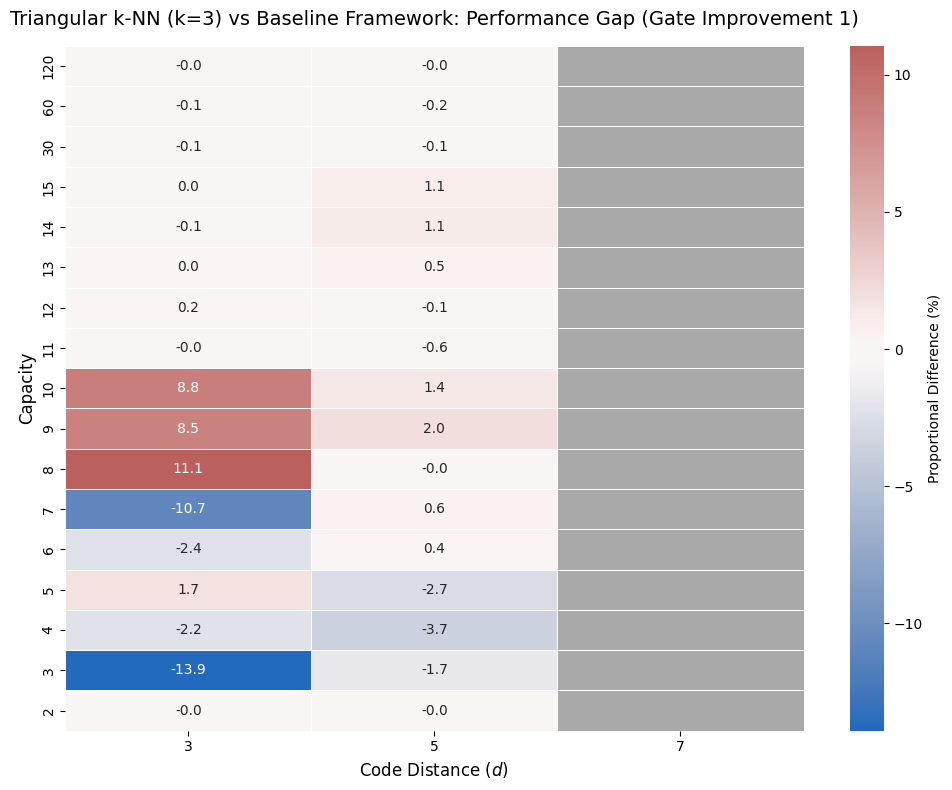

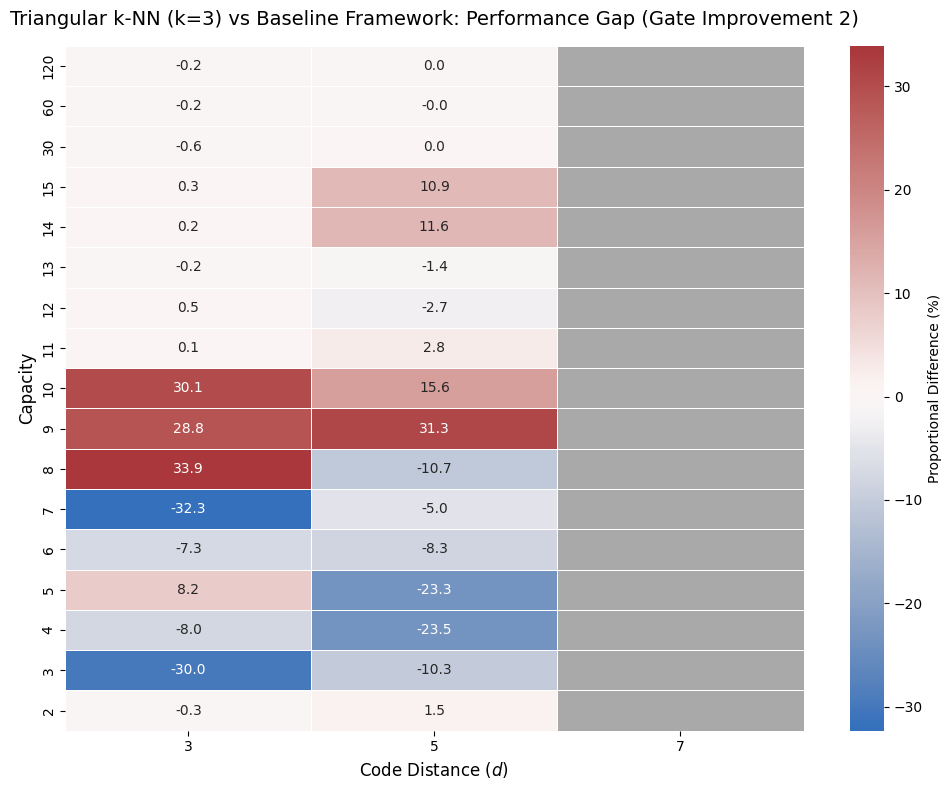

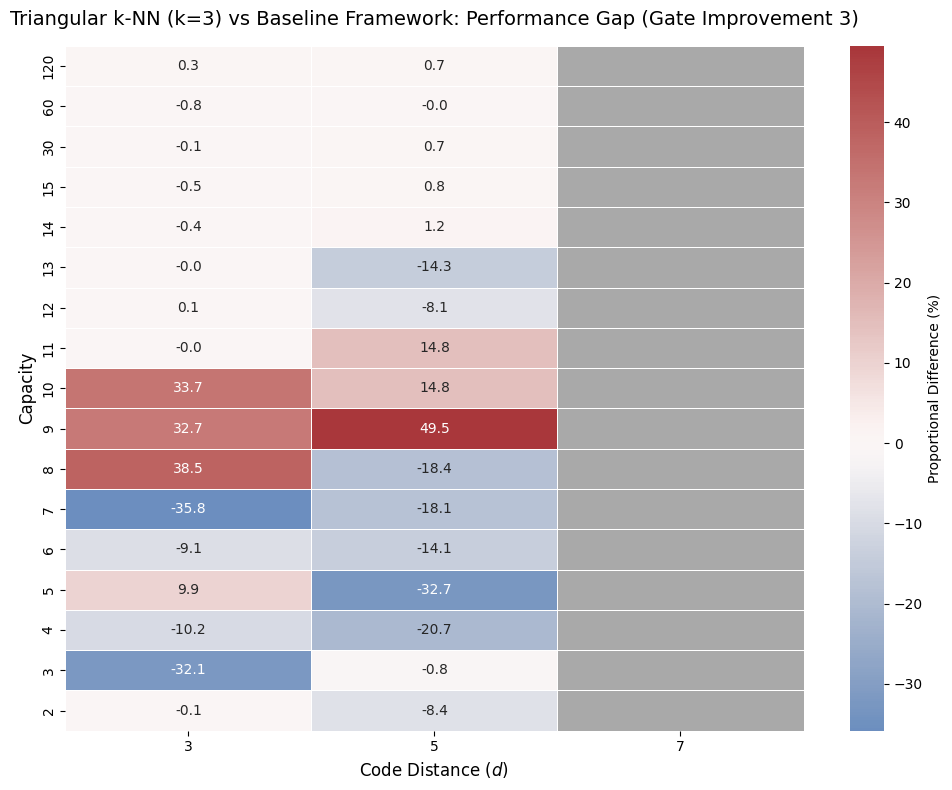

In [24]:
#heatmap generation for 2-round circuit with additional perfect syndrome extraction at end
baseline_path = r".\data\cc_halving010426.json"
data_path = r".\data\cc_k=3_nn010426.json"

generate_log_ratio_heatmaps(baseline_path, data_path, label_baseline="Baseline Framework", label_new="Triangular k-NN (k=3)")

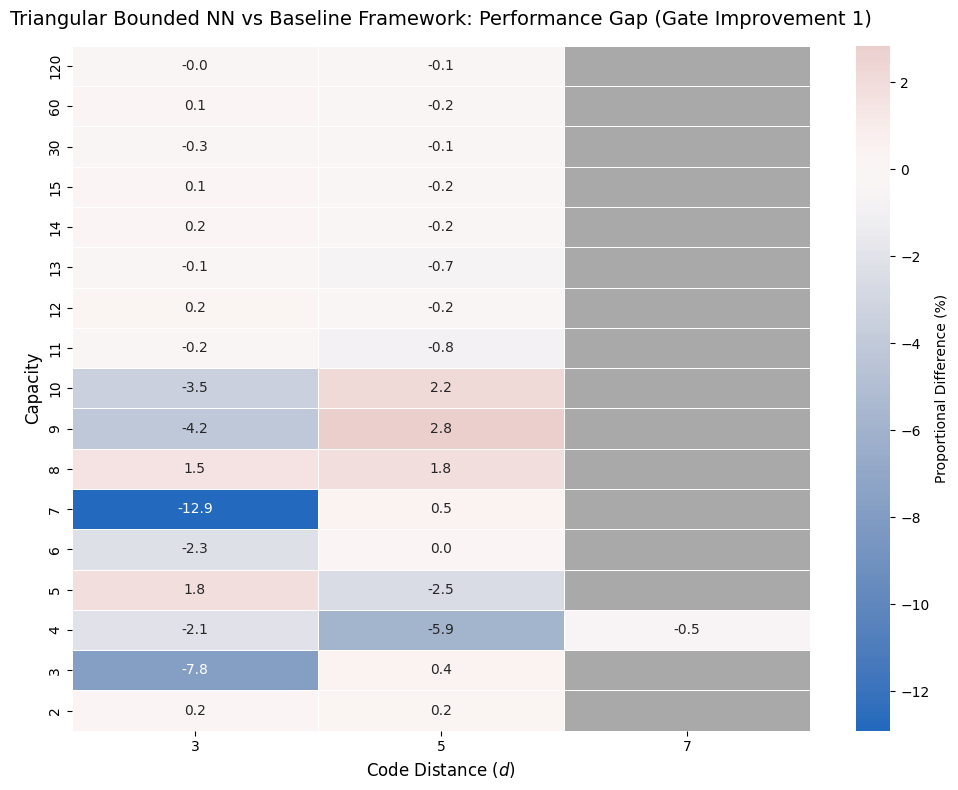

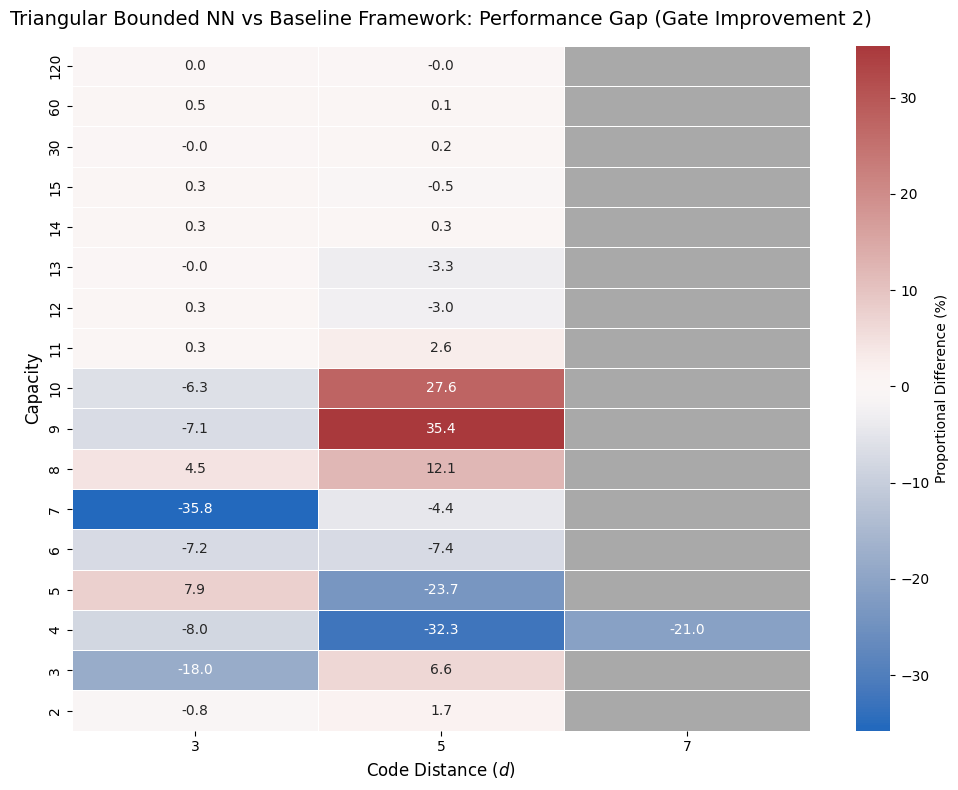

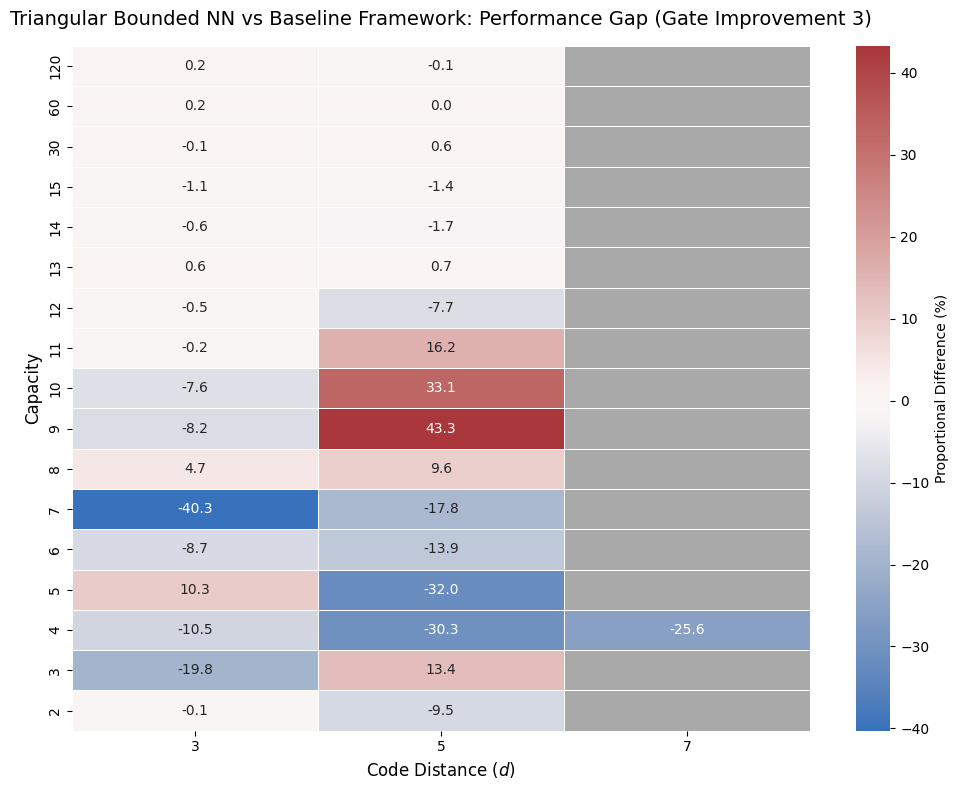

In [22]:
#heatmap generation for 2-round circuit with additional perfect syndrome extraction at end
baseline_path = r".\data\cc_halving010426.json"
data_path = r".\data\cc_merging_bounded_nn010426.json"

generate_performance_heatmaps(baseline_path, data_path, label_baseline="Baseline Framework", label_new="Triangular Bounded NN")